# (S)NPE-C on unif_norm

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/npe_c/"

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


# Amortized NPE-C

Below, we plot the posterior approximation for amortized posteriors trained with varying `num_simulations`

In [2]:
multiple_amortized_posteriors_ID = 0
multiple_amortized_posteriors_name = f"multiple_amortized_posteriors_dict{multiple_amortized_posteriors_ID}"
path_to_multiple_amortized_posteriors = results_path + multiple_amortized_posteriors_name + ".pkl"

# Load dictionary of posteriors, density estimators, and configs
with open(path_to_multiple_amortized_posteriors, "rb") as f:
    multiple_amortized_posteriors_dict = pickle.load(f)

multiple_amortized_posteriors_list = multiple_amortized_posteriors_dict["amortized_posteriors"]
multiple_amortized_posteriors_configs_list = multiple_amortized_posteriors_dict["configs"]
multiple_amortized_posteriors_density_estimators_list = multiple_amortized_posteriors_dict["density_estimators"]

L = multiple_amortized_posteriors_configs_list[0]["L"]
U = multiple_amortized_posteriors_configs_list[0]["U"]
d = multiple_amortized_posteriors_configs_list[0]["d"]
sigma = multiple_amortized_posteriors_configs_list[0]["sigma"]

In [3]:
# Following code only works for d=1
x_observed = 0.8
num_plotting_samples = 10000
num_simulations_list = [multiple_amortized_posteriors_configs["num_simulations"] for multiple_amortized_posteriors_configs in multiple_amortized_posteriors_configs_list]
amortized_density_estimator_samples_list = [amortized_density_estimator.sample((num_plotting_samples,), condition=torch.tensor([[x_observed]])).detach().view(-1) for amortized_density_estimator in multiple_amortized_posteriors_density_estimators_list]
amortized_posterior_samples_list = [amortized_posterior.sample((num_plotting_samples,), x=x_observed, show_progress_bars=False).view(-1) for amortized_posterior in multiple_amortized_posteriors_list]

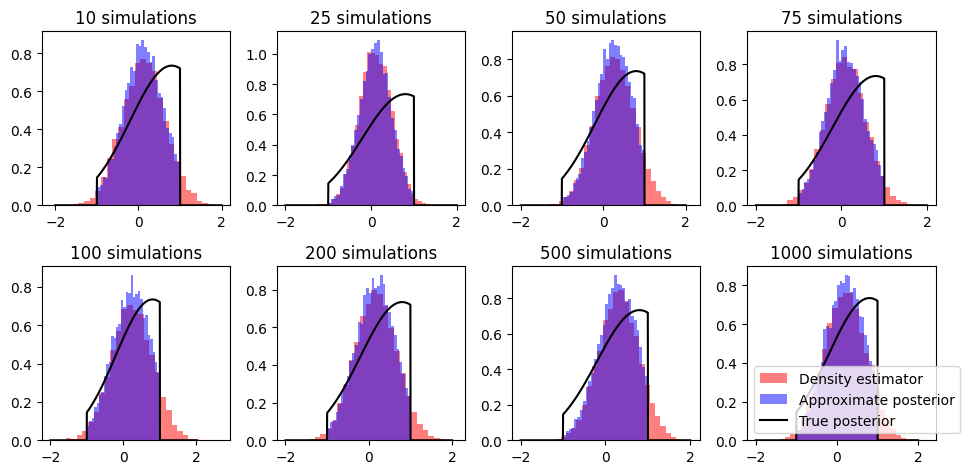

In [4]:
nrows, ncols = 2, 4
assert ncols * nrows == len(multiple_amortized_posteriors_list)
fig, ax = plt.subplots(figsize=(10,5), ncols=ncols, nrows=nrows)
#xlim0 = min([min(amortized_density_estimator_samples) for amortized_density_estimator_samples in amortized_density_estimator_samples_list])
#xlim1 = max([max(amortized_density_estimator_samples) for amortized_density_estimator_samples in amortized_density_estimator_samples_list])
mu_range = np.linspace(L-1, U+1, 1000)

bins=30
for k in range(len(multiple_amortized_posteriors_list)):
    i = k // ncols
    j = k % ncols
    ax[i,j].hist(amortized_density_estimator_samples_list[k], bins=bins, density=True, color="red", alpha=0.5, label="Density estimator")
    ax[i,j].hist(amortized_posterior_samples_list[k], bins=bins, density=True, color="blue", alpha=0.5, label="Approximate posterior")
    ax[i,j].plot(mu_range, true_posterior_pdf(mu_range, x_observed, L=L, U=U, sigma=sigma), color="k", label="True posterior")
    num_simulations = num_simulations_list[k]
    ax[i,j].set_title(f"{num_simulations} simulations")
    if k == len(multiple_amortized_posteriors_list) - 1:
        ax[i,j].legend()
title = ""
plt.suptitle(title)
plt.tight_layout()
plt.show()

Below, we plot the posterior approximation for a specific amortized posterior

In [5]:
amortized_posterior_ID = 0

# Load pre-trained amortized posterior
amortized_posterior_name = f"amortized_posterior{amortized_posterior_ID}"
path_to_amortized_posterior = results_path + amortized_posterior_name + ".pkl"
path_to_amortized_posterior_density_estimator = results_path + amortized_posterior_name + "_density_estimator" + ".pkl"
path_to_amortized_posterior_config = results_path + amortized_posterior_name + ".yaml"
path_to_amortized_posterior_simulations = results_path + amortized_posterior_name + "_simulations" + ".npz"

# Load posterior
with open(path_to_amortized_posterior, "rb") as f:
    amortized_posterior = pickle.load(f)

# Load density estimator
with open(path_to_amortized_posterior_density_estimator, "rb") as f:
    amortized_density_estimator = pickle.load(f)

# Turn DirectPosterior object into callable function
approximate_posterior_amortized = get_approximate_posterior_density(amortized_posterior)

# Load config
with open(path_to_amortized_posterior_config, "r") as f:
    amortized_posterior_config = yaml.safe_load(f)

# Load samples
amortized_posterior_simulations = np.load(path_to_amortized_posterior_simulations)

sigma = amortized_posterior_config["sigma"]
d = amortized_posterior_config["d"]
L = amortized_posterior_config["L"]
U = amortized_posterior_config["U"]

print("Amortized posterior config:")
amortized_posterior_config

Amortized posterior config:


{'L': -1.0,
 'U': 1.0,
 'd': 1,
 'force_first_round_loss': False,
 'num_simulations': 20000,
 'sigma': 1.0,
 'simulation_time': 0.2916700419999998,
 'total_time': 22.253233584,
 'training_time': 21.961563542}

In [6]:
x_observed = 0.8
amortized_density_estimator_samples = amortized_density_estimator.sample((num_plotting_samples,), condition=torch.tensor([[x_observed]])).detach().view(-1)
amortized_posterior_samples = amortized_posterior.sample((num_plotting_samples,), x=x_observed, show_progress_bars=False).view(-1)

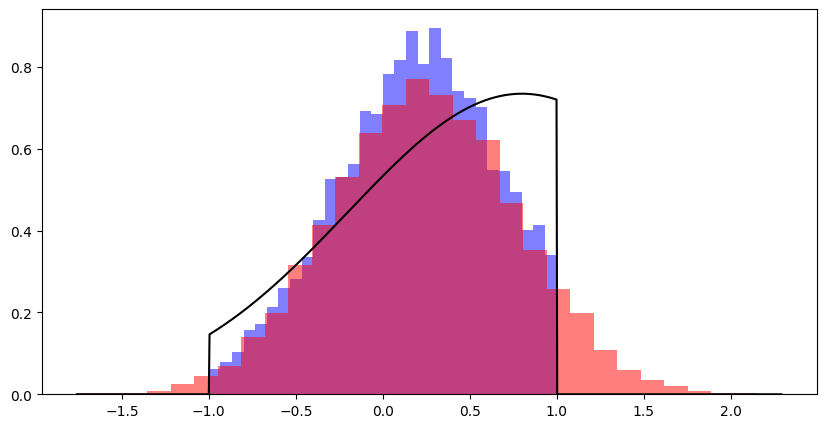

In [7]:
fig, ax = plt.subplots(figsize=(10,5))

xlim0 = min(amortized_density_estimator_samples)
xlim1 = max(amortized_density_estimator_samples)
mu_range = np.linspace(xlim0, xlim1, 1000)

# ADD AXES AND TITLE
ax.hist(amortized_posterior_samples, density=True, bins=bins, color="blue", alpha=0.5)
ax.hist(amortized_density_estimator_samples, density=True, bins=bins, color="red", alpha=0.5)
ax.plot(mu_range, true_posterior_pdf(mu_range, x_observed, L=L, U=U, sigma=sigma), color="black")

plt.show()

Below, we plot the leakage factor (proportion of density estimator area lying outside of $[L,U]^d$) against different hyperparameters:

In [8]:
amortized_leakage_factor_dict_d_ID = 6

amortized_leakage_factor_dict_d_name = f"amortized_leakage_factor_dict{amortized_leakage_factor_dict_d_ID}"
path_to_amortized_leakage_factor_dict_d = results_path + amortized_leakage_factor_dict_d_name + ".npz"
path_to_amortized_leakage_factor_dict_d_config = results_path + amortized_leakage_factor_dict_d_name + ".yaml"

# Load leakage factors
amortized_leakage_factor_dict_d = np.load(path_to_amortized_leakage_factor_dict_d)
amortized_leakage_factor_dict_d = dict(amortized_leakage_factor_dict_d)
# Convert keys of the form "d = 1" to int(1)
amortized_leakage_factor_dict_d = {int(k[4:]): v for k,v in amortized_leakage_factor_dict_d.items()}
# Load config
with open(path_to_amortized_leakage_factor_dict_d_config, "r") as f:
    amortized_leakage_factor_dict_d_config = yaml.safe_load(f)

amortized_leakage_factor_dict_d_config

{'L': -1.0,
 'U': 1.0,
 'd': 1,
 'd_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 'force_first_round_loss': False,
 'num_posterior_samples_per_leakage_factor': 10000,
 'num_posteriors_per_leakage_factor': 20,
 'num_simulations': 20000,
 'num_simulations_list': None,
 'runtimes_dict': {'d = 1': [91.42896732400004,
   37.418225381999946,
   69.88725430100021,
   29.898555219000627,
   41.68348893899929,
   44.8856490929993,
   96.90414956200038,
   50.53720042100031,
   43.64248352100003,
   48.04216061599982,
   73.10214111499954,
   40.57155366100051,
   56.966637611001715,
   67.92788962600025,
   47.11432760000025,
   61.3227546399994,
   60.09025701599967,
   70.6885504969996,
   26.48607484599961,
   47.17220140399877],
  'd = 10': [74.1356925670043,
   165.29034499800036,
   84.89374345100077,
   77.99150006200216,
   75.3500159260002,
   245.70663599300315,
   277.56834574499953,
   194.33705701299914,
   226.1390924599982,
   247.95467002299847,
   89.63060540

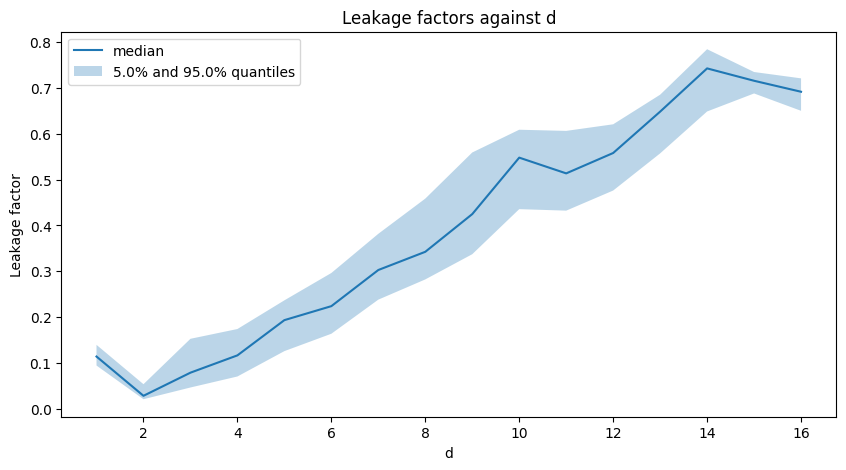

In [9]:
plot_leakage_factors(amortized_leakage_factor_dict_d, type="d")

In [10]:
amortized_leakage_factor_dict_ns_ID = 5

amortized_leakage_factor_dict_ns_name = f"amortized_leakage_factor_dict{amortized_leakage_factor_dict_ns_ID}"
path_to_amortized_leakage_factor_dict_ns = results_path + amortized_leakage_factor_dict_ns_name + ".npz"
path_to_amortized_leakage_factor_dict_ns_config = results_path + amortized_leakage_factor_dict_ns_name + ".yaml"

# Load leakage factors
amortized_leakage_factor_dict_ns = np.load(path_to_amortized_leakage_factor_dict_ns)
amortized_leakage_factor_dict_ns = dict(amortized_leakage_factor_dict_ns)
# Convert keys of the form "num_simulations = 1" to int(1)
amortized_leakage_factor_dict_ns = {int(k[18:]): v for k,v in amortized_leakage_factor_dict_ns.items()}
# Load config
with open(path_to_amortized_leakage_factor_dict_ns_config, "r") as f:
    amortized_leakage_factor_dict_ns_config = yaml.safe_load(f)

amortized_leakage_factor_dict_ns_config

{'L': -1.0,
 'U': 1.0,
 'd': 10,
 'd_list': None,
 'force_first_round_loss': False,
 'num_posterior_samples_per_leakage_factor': 10000,
 'num_posteriors_per_leakage_factor': 20,
 'num_simulations': 20000,
 'num_simulations_list': [50,
  100,
  250,
  500,
  1000,
  2500,
  5000,
  10000,
  20000,
  50000,
  100000],
 'runtimes_dict': {'num_simulations = 100': [3.2913162329987244,
   3.113458885,
   2.6484789199985244,
   3.398721920999378,
   3.028595720001249,
   3.000235261999478,
   2.378951844999392,
   3.3505308240000886,
   2.353410743000495,
   3.0470317710005475,
   2.7607157559996267,
   2.7001790610011085,
   3.2539137240000855,
   3.520409949000168,
   3.541024150999874,
   3.6428592889988067,
   3.295482503999665,
   2.7197559930009447,
   2.4949318309991213,
   3.15538686400032],
  'num_simulations = 1000': [6.05769434099966,
   7.287898777000009,
   8.870417545998862,
   7.851218767000319,
   6.7389898220008035,
   7.990201055001307,
   8.154071705001115,
   9.27475814500

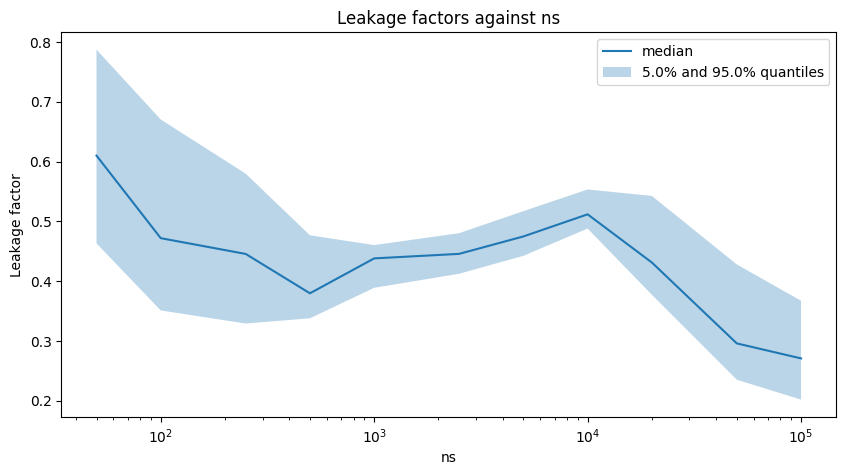

In [11]:
plot_leakage_factors(amortized_leakage_factor_dict_ns, type="ns", logscale=True)

# Sequential NPE-C (SNPE-C)

Below, we plot the posterior approximation for sequential posteriors trained with varying `(num_sequential_rounds, num_simulations_per_round)`

In [12]:
multiple_sequential_posteriors_ID = 1
multiple_sequential_posteriors_name = f"multiple_sequential_posteriors_dict{multiple_sequential_posteriors_ID}"
path_to_multiple_sequential_posteriors = results_path + multiple_sequential_posteriors_name + ".pkl"

# Load dictionary of posteriors, density estimators, and configs
with open(path_to_multiple_sequential_posteriors, "rb") as f:
    multiple_sequential_posteriors_dict = pickle.load(f)

multiple_sequential_posteriors_list = multiple_sequential_posteriors_dict["sequential_posteriors"]
multiple_sequential_posteriors_configs_list = multiple_sequential_posteriors_dict["configs"]
multiple_sequential_posteriors_density_estimators_list = multiple_sequential_posteriors_dict["density_estimators"]

L = multiple_sequential_posteriors_configs_list[0]["L"]
U = multiple_sequential_posteriors_configs_list[0]["U"]
d = multiple_sequential_posteriors_configs_list[0]["d"]
sigma = multiple_sequential_posteriors_configs_list[0]["sigma"]
x_observed = multiple_sequential_posteriors_configs_list[0]["x_observed"]


In [13]:
num_plotting_samples = 10000
num_simulations_per_round_list = [multiple_sequential_posteriors_configs["num_simulations_per_round"] for multiple_sequential_posteriors_configs in multiple_sequential_posteriors_configs_list]
num_sequential_rounds_list = [multiple_sequential_posteriors_configs["num_sequential_rounds"] for multiple_sequential_posteriors_configs in multiple_sequential_posteriors_configs_list]

sequential_density_estimator_samples_list = [sequential_density_estimator.sample((num_plotting_samples,), condition=torch.tensor([[x_observed]])).detach().view(-1) for sequential_density_estimator in multiple_sequential_posteriors_density_estimators_list]
sequential_posterior_samples_list = [sequential_posterior.sample((num_plotting_samples,), x=x_observed, show_progress_bars=False).view(-1) for sequential_posterior in multiple_sequential_posteriors_list]
leakage_rate_list = [torch.sum((sequential_density_estimator_samples < L) | (sequential_density_estimator_samples > U)) / num_plotting_samples for sequential_density_estimator_samples in sequential_density_estimator_samples_list]

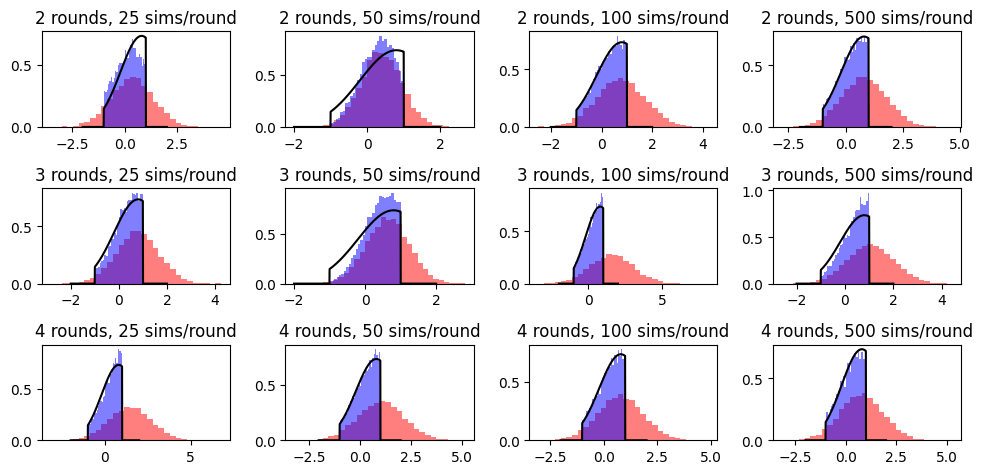

In [14]:
nrows, ncols = 3, 4
assert ncols * nrows == len(multiple_sequential_posteriors_list)
fig, ax = plt.subplots(figsize=(10,5), ncols=ncols, nrows=nrows)
#xlim0 = min([min(sequential_density_estimator_samples) for sequential_density_estimator_samples in sequential_density_estimator_samples_list])
#xlim1 = max([max(sequential_density_estimator_samples) for sequential_density_estimator_samples in sequential_density_estimator_samples_list])
mu_range = np.linspace(L-1, U+1, 1000)

bins=30
for k in range(len(multiple_sequential_posteriors_list)):
    i = k // ncols
    j = k % ncols
    ax[i,j].hist(sequential_density_estimator_samples_list[k], bins=bins, density=True, color="red", alpha=0.5)
    ax[i,j].hist(sequential_posterior_samples_list[k], bins=bins, density=True, color="blue", alpha=0.5)
    ax[i,j].plot(mu_range, true_posterior_pdf(mu_range, x_observed, L=L, U=U, sigma=sigma), color="k")
    num_simulations_per_round = num_simulations_per_round_list[k]
    num_sequential_rounds = num_sequential_rounds_list[k]
    ax[i,j].set_title(f"{num_sequential_rounds} rounds, {num_simulations_per_round} sims/round")

title = ""
plt.suptitle(title)
plt.tight_layout()
plt.show()

Below, we plot the posterior approximation for a specific sequential posterior

In [15]:
sequential_posterior_ID = 0

# Load pre-trained posterior
sequential_posterior_name = f"sequential_posterior{sequential_posterior_ID}"
path_to_sequential_posterior = results_path + sequential_posterior_name + ".pkl"
path_to_sequential_density_estimator = results_path + sequential_posterior_name + "_density_estimator" + ".pkl"
path_to_sequential_posterior_config = results_path + sequential_posterior_name + ".yaml"
path_to_sequential_posterior_simulations = results_path + sequential_posterior_name + "_simulations" + ".npz"

# Load posterior
with open(path_to_sequential_posterior, "rb") as f:
    sequential_posterior = pickle.load(f)

# Load density estimator
with open(path_to_sequential_density_estimator, "rb") as f:
    sequential_density_estimator = pickle.load(f)

# Load config
with open(path_to_sequential_posterior_config, "r") as f:
    sequential_posterior_config = yaml.safe_load(f)

# Load samples
sequential_posterior_simulations = np.load(path_to_sequential_posterior_simulations)

x_observed = sequential_posterior_config["x_observed"]
sigma = sequential_posterior_config["sigma"]
d = sequential_posterior_config["d"]
L = sequential_posterior_config["L"]
U = sequential_posterior_config["U"]
num_sequential_rounds = sequential_posterior_config["num_sequential_rounds"]
num_simulations_per_round = sequential_posterior_config["num_simulations_per_round"]

print("Sequential posterior config:")
sequential_posterior_config

Sequential posterior config:


{'L': -1.0,
 'U': 1.0,
 'd': 1,
 'num_sequential_rounds': 4,
 'num_simulations_per_round': 5000,
 'density_estimator': 'maf',
 'sigma': 1.0,
 'simulation_times': [0.3028554590000003,
  0.0359967499999998,
  0.04009983400000294,
  0.029616457999999568],
 'total_time': 71.30190879300001,
 'training_times': [3.291137917,
  18.430604375,
  26.985046208000004,
  22.186551791999996],
 'use_combined_loss': False,
 'x_observed': 0.8}

In [16]:
sequential_density_estimator_samples = sequential_density_estimator.sample((num_plotting_samples,), condition=torch.tensor([[x_observed]])).detach().view(-1)
sequential_posterior_samples = sequential_posterior.sample((num_plotting_samples,), x=x_observed, show_progress_bars=False).view(-1)

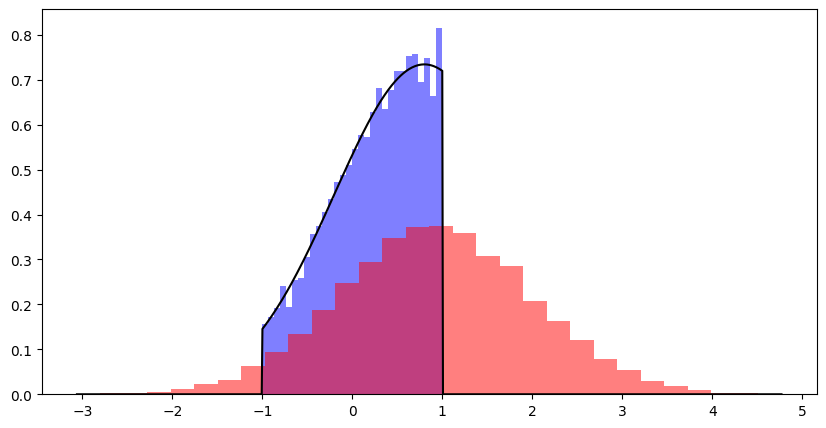

In [17]:
fig, ax = plt.subplots(figsize=(10,5))

xlim0 = min(sequential_density_estimator_samples)
xlim1 = max(sequential_density_estimator_samples)
mu_range = np.linspace(xlim0, xlim1, 1000)

# ADD AXES AND TITLE
ax.hist(sequential_posterior_samples, density=True, bins=bins, color="blue", alpha=0.5)
ax.hist(sequential_density_estimator_samples, density=True, bins=bins, color="red", alpha=0.5)
ax.plot(mu_range, true_posterior_pdf(mu_range, x_observed, L=L, U=U, sigma=sigma), color="black")

plt.show()

Below, we plot the leakage factor (proportion of density estimator area lying outside of $[L,U]^d$) against different hyperparameters:

In [18]:
sequential_leakage_factor_dict_d_ID = 2

sequential_leakage_factor_dict_d_name = f"sequential_leakage_factor_dict{sequential_leakage_factor_dict_d_ID}"
path_to_sequential_leakage_factor_dict_d = results_path + sequential_leakage_factor_dict_d_name + ".npz"
path_to_sequential_leakage_factor_dict_d_config = results_path + sequential_leakage_factor_dict_d_name + ".yaml"

# Load leakage factors
sequential_leakage_factor_dict_d = np.load(path_to_sequential_leakage_factor_dict_d)
sequential_leakage_factor_dict_d = dict(sequential_leakage_factor_dict_d)
# Convert keys of the form "d = 1" to int(1)
sequential_leakage_factor_dict_d = {int(k[4:]): v for k,v in sequential_leakage_factor_dict_d.items()}

# Load config
with open(path_to_sequential_leakage_factor_dict_d_config, "r") as f:
    sequential_leakage_factor_dict_d_config = yaml.safe_load(f)

sequential_leakage_factor_dict_d_config

{'L': -1.0,
 'U': 1.0,
 'd': 1,
 'd_list': [1, 4, 8, 12, 16, 20],
 'num_posterior_samples_per_leakage_factor': 10000,
 'num_posteriors_per_leakage_factor': 20,
 'num_sequential_rounds': 4,
 'density_estimator': 'maf',
 'num_sequential_rounds_list': None,
 'num_simulations_per_round': 5000,
 'num_simulations_per_round_list': None,
 'runtimes_dict': {'d = 1': [262.6952581780006,
   269.4708477059994,
   270.3858599190007,
   257.82363845799955,
   460.0009471270005,
   313.1125903989996,
   284.1466697550004,
   355.32264189299894,
   254.1663869519998,
   365.1431756150014,
   280.2036614789995,
   305.7203323039994,
   325.24592152600053,
   284.0472540869996,
   371.69254664399887,
   319.50829372799853,
   376.92048290699677,
   264.9942762380015,
   331.8906814910006,
   252.20124111999758],
  'd = 12': [377.49756482099474,
   488.0631726069987,
   416.53252351699484,
   456.93730701700406,
   331.28742644999875,
   389.26151135299733,
   427.39205663800385,
   370.53111440000066,
 

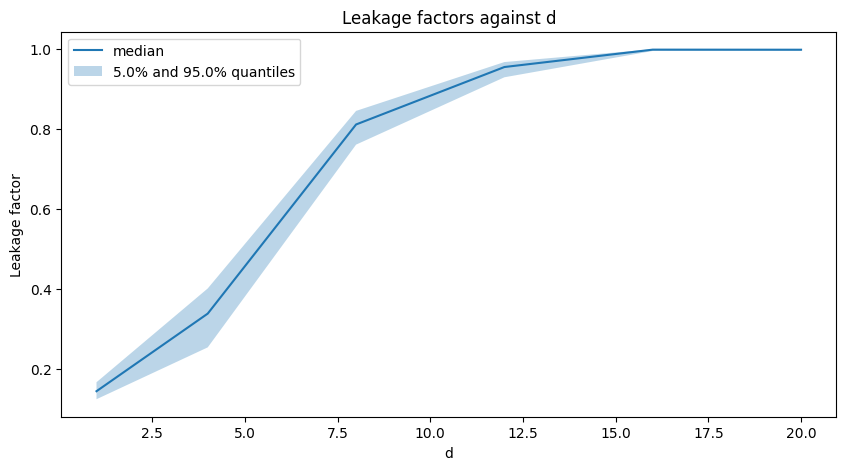

In [19]:
plot_leakage_factors(sequential_leakage_factor_dict_d, type="d")

In [20]:
sequential_leakage_factor_dict_nr_nspr_ID = 3

sequential_leakage_factor_dict_nr_nspr_name = f"sequential_leakage_factor_dict{sequential_leakage_factor_dict_nr_nspr_ID}"
path_to_sequential_leakage_factor_dict_nr_nspr = results_path + sequential_leakage_factor_dict_nr_nspr_name + ".npz"
path_to_sequential_leakage_factor_dict_nr_nspr_config = results_path + sequential_leakage_factor_dict_nr_nspr_name + ".yaml"

# Load leakage factors
sequential_leakage_factor_dict_nr_nspr = np.load(path_to_sequential_leakage_factor_dict_nr_nspr)
sequential_leakage_factor_dict_nr_nspr = dict(sequential_leakage_factor_dict_nr_nspr)
import ast
# Convert keys of the form "(nr, nspr) = (1,1)" to "(1,1)"
sequential_leakage_factor_dict_nr_nspr = {ast.literal_eval(k[53:]): v for k,v in sequential_leakage_factor_dict_nr_nspr.items()}

# Load config
with open(path_to_sequential_leakage_factor_dict_nr_nspr_config, "r") as f:
    sequential_leakage_factor_dict_nr_nspr_config = yaml.safe_load(f)

sequential_leakage_factor_dict_nr_nspr_config

{'L': -1.0,
 'U': 1.0,
 'd': 10,
 'd_list': None,
 'num_posterior_samples_per_leakage_factor': 10000,
 'num_posteriors_per_leakage_factor': 100,
 'num_sequential_rounds': 4,
 'density_estimator': 'maf',
 'num_sequential_rounds_list': [2, 2, 2, 3, 3, 3, 4, 4, 4],
 'num_simulations_per_round': 5000,
 'num_simulations_per_round_list': [100,
  1000,
  10000,
  100,
  1000,
  10000,
  100,
  1000,
  10000],
 'runtimes_dict': {'(num_sequential_rounds, num_simulations_per_round) = (2, 100)': [21.698655570857227,
   7.612971210852265,
   5.285118906758726,
   5.737583310343325,
   5.087928576394916,
   5.03438052162528,
   5.678887277841568,
   7.522100141271949,
   6.00223483517766,
   5.497892510145903,
   4.9896245785057545,
   7.280667315237224,
   6.810401537455618,
   4.709310948848724,
   5.008112641982734,
   5.487290967255831,
   6.284530649892986,
   5.498261739499867,
   5.005084032192826,
   4.134122136980295,
   4.27429885789752,
   6.273963637650013,
   6.017283504828811,
   5.43

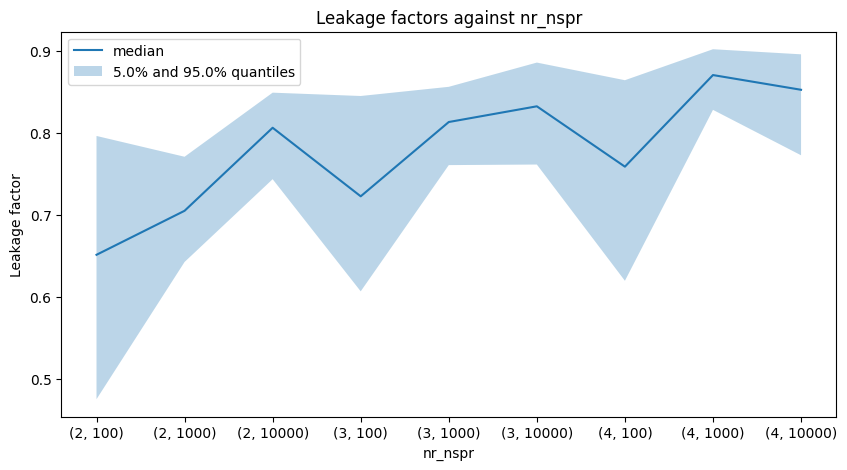

In [21]:
plot_leakage_factors(sequential_leakage_factor_dict_nr_nspr, type="nr_nspr")